In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import squareform  
from skimage.measure import regionprops_table
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
import networkx as nx
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import BoundaryNorm
from scipy.spatial import cKDTree, Delaunay
from itertools import combinations

XY_UM = 0.1893014                    # micron per pixel in x/y
Z_UM = 0.7996567                     # micron per pixel in z
IMAGE_KEY = "source_folder"          # one physical image per source_folder

MAX_CLUSTERS = 12                     # largest K the Bernoulli BIC search may pick per lineage
SPATIAL_RADIUS_UM = 30.0             # Delaunay edges <= this distance (same image) define neighbours
N_PERM = 200                         # permutations for the spatial neighbour-enrichment null
endo_genes = ["CDH5", "PECAM1", "VWF", "KDR", "FLT1", "PDGFB"]
fibro_genes = ["PDGFRB", "COL1A1", "COL1A2"]
genes = ['CDH5', 'MMP1', 'COL1A1', 'KDR', 'VWF', 'PECAM1', 'VEGFA', 'DLL4', 'ITGA6', 'SEMA3F', 'JAG1', 'FLT1', 'PDGFB', 'COL1A2', 'APLN', 'PDGFRB', 'ANGPT2', 'ICAM1']



endo_marker_genes = ["CDH5", "VWF", "PECAM1"]   # pan-endothelial markers: ON everywhere, so no module info
fibro_marker_genes = ["COL1A1", "COL1A2", "PDGFRB"]         # collagen genes: fibroblast, not part of the endothelial modules
combined_marker_genes = set(endo_marker_genes) | set(fibro_marker_genes)
endothelial_genes_of_interest = [g for g in genes if g not in set(endo_marker_genes) | set(fibro_marker_genes)]
min_on = 20                                         # a gene must be ON in >= this many cells to form an edge

all_data = pd.read_csv("clean_data_with_assigned_cell_type.csv")


all_data["binary_state"] = all_data[genes].astype(int).astype(str).agg("".join, axis=1)
X = all_data[genes].astype(int).to_numpy()


In [36]:
# Build the phi-weighted, significant-positive edge set the module graph is made from.
# endothelial_genes_of_interest already excludes the pan-endothelial markers + collagen (see config cell).
B = all_data[(all_data["cell_type"] == "Endothelial") & all_data["has_reads"]][endothelial_genes_of_interest].to_numpy()
on_count = B.sum(0)
on_freq = B.mean(0)

rows = []
for i in range(len(endothelial_genes_of_interest)):
    for j in range(i + 1, len(endothelial_genes_of_interest)):
        a = int(((B[:, i] == 1) & (B[:, j] == 1)).sum())      # both on
        b = int(on_count[i]) - a
        c = int(on_count[j]) - a
        d = len(B) - a - b - c
        _, p = fisher_exact([[a, b], [c, d]])
        odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
        denom = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
        phi = (a * d - b * c) / denom if denom else 0.0        # Matthews correlation of the two 0/1 vectors
        rows.append((endothelial_genes_of_interest[i], endothelial_genes_of_interest[j], np.log2(odds), phi, p,
                     int(on_count[i]), int(on_count[j])))

gene_pairs = pd.DataFrame(rows, columns=["gene1", "gene2", "log2_OR", "phi", "pvalue", "n1", "n2"])
gene_pairs["FDR"] = multipletests(gene_pairs.pvalue, method="fdr_bh")[1]

# Edges = significant positive co-occurrences with both genes ON in >= min_on cells; weight = phi.
positive_pairs = gene_pairs[(gene_pairs.log2_OR > 0) & (gene_pairs.FDR < 0.05) & (gene_pairs.n1 >= min_on) & (gene_pairs.n2 >= min_on)].copy()
print(f"{len(positive_pairs)} significant positive edges over {len(endothelial_genes_of_interest)} endothelial genes of interest")


44 significant positive edges over 12 endothelial genes of interest


{'ICAM1': 0, 'ANGPT2': 0, 'APLN': 0, 'PDGFB': 0, 'JAG1': 0, 'DLL4': 1, 'FLT1': 1, 'SEMA3F': 1, 'MMP1': 1, 'ITGA6': 2, 'VEGFA': 2, 'KDR': 2}
['dodgerblue', 'limegreen', 'limegreen', 'dodgerblue', 'limegreen', 'dodgerblue', 'darkorange', 'dodgerblue', 'darkorange', 'darkorange', 'darkorange', 'darkorange']


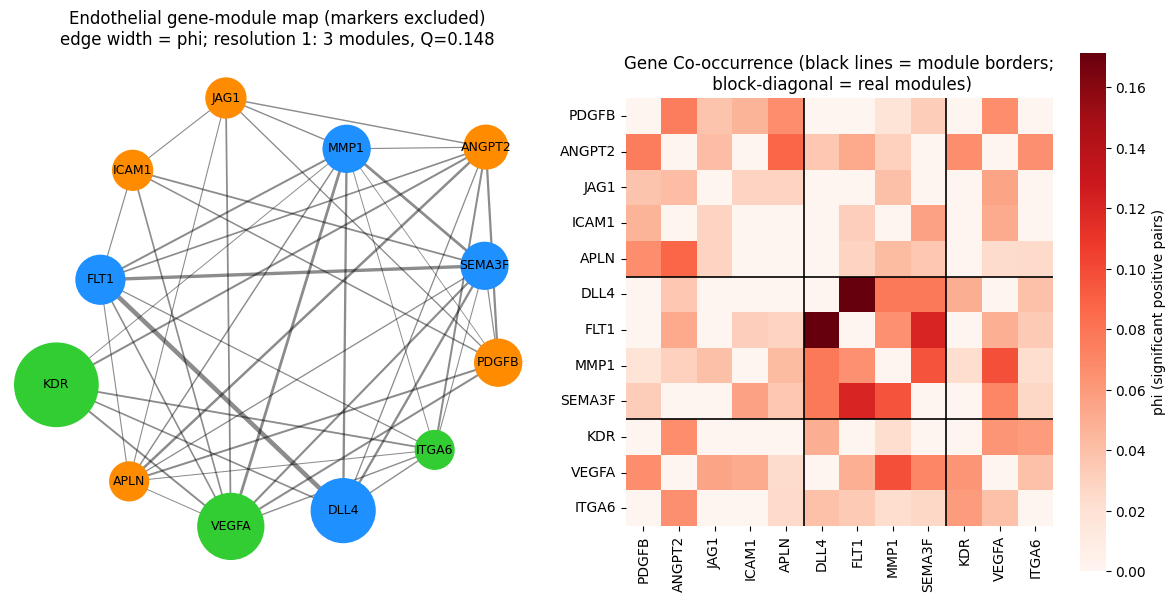

In [37]:
RESOLUTION = 1
Gp = nx.Graph()
Gp.add_nodes_from(endothelial_genes_of_interest)
for r in positive_pairs.itertuples():
    Gp.add_edge(r.gene1, r.gene2, weight=float(r.phi))

communities = list(nx.community.greedy_modularity_communities(Gp, weight="weight", resolution=RESOLUTION))
# greedy_modularity_communities(...) is a community-detection algorithm. 
# It starts with every gene in its own community, then repeatedly asks which two communities should be merged 
# to increase the overall modularity the most. It stops when no further merge improves modularity.
# Are there more/stronger connections inside these proposed modules than we would expect given how connected 
# the genes are overall?
Q = nx.community.modularity(Gp, communities, weight="weight")
module_dict = {gene: m for m, com in enumerate(communities) for gene in com}
print(module_dict)
n_mod = len(communities)

# --- Left: the gene-module map (edge width = phi, node colour = module, node size = ON frequency) ---
# module_cmap = plt.get_cmap("tab10", max(n_mod, 1))
module_cmap = ["darkorange", "dodgerblue", "limegreen"]
connected = [g for g in Gp.nodes() if Gp.degree(g) > 0]
H = Gp.subgraph(connected)
layout = nx.spring_layout(H, weight="weight", k=1.4, seed=1)
node_size = [600 + 3000 * on_freq[endothelial_genes_of_interest.index(g)] / on_freq.max() for g in H.nodes()]
node_color = [module_cmap[module_dict[g]] for g in H.nodes()]
print(node_color)
ew = np.array([H[u][v]["weight"] for u, v in H.edges()])
edge_width = 0.3 + 3.0 * ew / ew.max()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
nx.draw_networkx_edges(H, layout, ax=ax[0], width=edge_width, alpha=0.45)
nx.draw_networkx_nodes(H, layout, ax=ax[0], node_size=node_size, node_color=node_color)
nx.draw_networkx_labels(H, layout, ax=ax[0], font_size=9)
ax[0].set_title(f"Endothelial gene-module map (markers excluded)\n"
                 f"edge width = phi; resolution {RESOLUTION}: {n_mod} modules, Q={Q:.3f}")
ax[0].axis("off")

# --- Right: co-occurrence matrix ORDERED BY MODULE. Real modules = block-diagonal. ---
order = [g for com in communities for g in sorted(com, key=lambda x: -on_freq[endothelial_genes_of_interest.index(x)])]
M = pd.DataFrame(0.0, index=order, columns=order)
for r in positive_pairs.itertuples():
    M.loc[r.gene1, r.gene2] = r.phi
    M.loc[r.gene2, r.gene1] = r.phi
sns.heatmap(M, cmap="Reds", square=True, ax=ax[1],
            cbar_kws={"label": "phi (significant positive pairs)"})
for bnd in np.cumsum([len(c) for c in communities])[:-1]:
    ax[1].axhline(bnd, color="k", lw=1.2); ax[1].axvline(bnd, color="k", lw=1.2)
ax[1].set_title("Gene Co-occurrence (black lines = module borders;\n block-diagonal = real modules)")
plt.tight_layout();
plt.show()

In [38]:
def fit_bernoulli_mixture_once(gene_matrix, n_states, max_iter=300, tol=1e-6, rng=None):
    """One EM run of a Bernoulli mixture.

    Returns (weights, on_probabilities, log_likelihood, responsibilities).
    """
    rng = rng if rng is not None else np.random.default_rng(0)
    n_cells, n_genes = gene_matrix.shape
    on_probabilities = rng.uniform(0.1, 0.9, size=(n_states, n_genes))
    weights = np.full(n_states, 1.0 / n_states)
    log_likelihood_prev = -np.inf
    responsibilities = np.full((n_cells, n_states), 1.0 / n_states)
    for iteration in range(max_iter):
        log_prob = (gene_matrix @ np.log(on_probabilities.T)
                    + (1 - gene_matrix) @ np.log(1 - on_probabilities.T)) + np.log(weights)
        row_max = log_prob.max(axis=1, keepdims=True)
        log_norm = row_max.ravel() + np.log(np.exp(log_prob - row_max).sum(axis=1))
        log_likelihood = log_norm.sum()
        responsibilities = np.exp(log_prob - log_norm[:, None])
        cells_per_state = responsibilities.sum(axis=0) + 1e-9
        weights = cells_per_state / n_cells
        on_probabilities = np.clip((responsibilities.T @ gene_matrix) / cells_per_state[:, None],
                                   1e-3, 1 - 1e-3)
        if abs(log_likelihood - log_likelihood_prev) < tol * (abs(log_likelihood_prev) + 1e-9):
            break
        log_likelihood_prev = log_likelihood
    return weights, on_probabilities, log_likelihood, responsibilities

def fit_bernoulli_mixture(gene_matrix, n_states, n_restarts=8, seed=0):
    """Sort cells into `n_states` hidden states using a Bernoulli mixture.

    The idea: imagine a few hidden cell states. Each state has, for every gene, a
    chance that the gene is switched on, and each cell is a slightly noisy copy of one
    state. Fitting the model tells us those states and which one each cell most likely
    belongs to. Because it is a probability model of how the on/off patterns arise, it
    is a good sanity check on the distance-based clustering. It assumes genes turn on
    independently within a state and that a 0 really means "off" (not just missed).

    Runs the fit several times from random starts and keeps the best. Returns a dict
    with the state weights, per-gene on-probabilities, one hard label per cell, the
    full soft responsibilities (cells x states), and the BIC score (lower = better fit
    once the number of states is penalised).
    """
    gene_matrix = np.asarray(gene_matrix, dtype=float)
    rng = np.random.default_rng(seed)
    best_fit = None
    for restart in range(n_restarts):
        candidate = fit_bernoulli_mixture_once(gene_matrix, n_states, rng=rng)
        if best_fit is None or candidate[2] > best_fit[2]:
            best_fit = candidate
    weights, on_probabilities, log_likelihood, responsibilities = best_fit
    labels = responsibilities.argmax(axis=1)
    n_cells, n_genes = gene_matrix.shape
    n_params = n_states * n_genes + (n_states - 1)
    bic = -2 * log_likelihood + n_params * np.log(n_cells)
    return {
        "n_states": n_states,
        "weights": weights,
        "on_probabilities": on_probabilities,
        "labels": labels,
        "responsibilities": responsibilities,
        "bic": bic,
    }


def select_bernoulli_mixture(gene_matrix, candidate_states=range(2, 11), seed=0):
    """Fit the mixture for several numbers of states and keep the lowest-BIC one.

    Returns (best_fit, fits_by_number_of_states).
    """
    fits_by_number_of_states = {
        n_states: fit_bernoulli_mixture(gene_matrix, n_states, seed=seed)
        for n_states in candidate_states
    }
    best_n_states = min(fits_by_number_of_states, key=lambda k: fits_by_number_of_states[k]["bic"])
    return fits_by_number_of_states[best_n_states], fits_by_number_of_states

In [39]:
#  Approach 3: Logistic PCA (continuous latent axes for binary data)
#
# Are the ~K Bernoulli states really a handful of discrete types, or positions along a
# few CONTINUOUS axes? Ordinary PCA assumes Gaussian data; here each gene is 0/1, so we
# use logistic PCA: model P(gene on) = sigmoid(mu_j + scores . loadings_j), i.e. the
# log-odds (natural parameters) are low-rank. Fitted with the majorization-minimization
# (MM) scheme of de Leeuw / Landgraf & Lee - at each step the logistic loss is bounded
# by a quadratic whose minimiser is a plain SVD of a "working response", so it reduces
# to repeated PCA and converges monotonically.

def sigmoid(natural_params):
    return 1.0 / (1.0 + np.exp(-np.clip(natural_params, -30, 30)))


def binary_deviance(binary_matrix, natural_params):
    """-2 * Bernoulli log-likelihood of `binary_matrix` given log-odds `natural_params`."""
    on_probability = np.clip(sigmoid(natural_params), 1e-9, 1 - 1e-9)
    return -2.0 * np.sum(binary_matrix * np.log(on_probability)
                         + (1 - binary_matrix) * np.log(1 - on_probability))


def fit_logistic_pca(binary_matrix, n_components, max_iter=200, tol=1e-6):
    """Logistic PCA of a binary (cells x genes) matrix via MM / iterated SVD.

    Models the log-odds as  Theta = mu + scores @ loadings.T  (rank n_components).
    Returns a dict with:
      mu         : per-gene intercept (log-odds of the marginal ON-rate),
      scores     : cells x n_components latent coordinates (the continuous axes),
      loadings   : genes x n_components gene weights on each axis,
      deviance   : -2 log-likelihood of the fitted rank-k model (lower = better).
    """
    binary_matrix = np.asarray(binary_matrix, dtype=float)
    n_cells, n_genes = binary_matrix.shape
    marginal_on_rate = np.clip(binary_matrix.mean(axis=0), 1e-3, 1 - 1e-3)
    mu = np.log(marginal_on_rate / (1 - marginal_on_rate))
    theta = np.tile(mu, (n_cells, 1))
    scores = np.zeros((n_cells, n_components))
    loadings = np.zeros((n_genes, n_components))
    deviance_prev = np.inf
    for iteration in range(max_iter):
        # MM working response: quadratic surrogate to the logistic loss (Hessian <= 1/4).
        working = theta + 4.0 * (binary_matrix - sigmoid(theta))
        mu = working.mean(axis=0)
        centred = working - mu
        left, singular_values, right = np.linalg.svd(centred, full_matrices=False)
        rank = min(n_components, len(singular_values))
        scores = left[:, :rank] * singular_values[:rank]
        loadings = right[:rank].T
        theta = mu + scores @ loadings.T
        deviance = binary_deviance(binary_matrix, theta)
        if abs(deviance_prev - deviance) < tol * (abs(deviance_prev) + 1e-9):
            break
        deviance_prev = deviance
    return {"mu": mu, "scores": scores, "loadings": loadings, "deviance": deviance}


In [40]:
def cluster_and_report(df, cell_type, max_clusters=8, k_min=2, 
                       lpca_max_components=6, exclude_genes=None, force_k=None):
    if cell_type is not None:
        df = df[(df["has_reads"]) & (df["cell_type"] == cell_type)].copy()
    else:
        df = df[df["has_reads"]].copy()
    exclude_genes = list(exclude_genes or [])
    genes_used = [g for g in genes if g not in set(exclude_genes)]
    matrix = df[genes_used].astype(int).to_numpy()
    print(f"POPULATION: {cell_type}  ({len(df):,} cells with reads)")
    

    # --- 1. Bernoulli mixture - BIC picks K (unless force_k overrides it) ---
    best_mixture, mixtures_by_k = select_bernoulli_mixture(
        matrix, candidate_states=range(k_min, max_clusters + 1))
    if force_k is not None:                       # manual override: fit exactly this many states
        best_mixture = mixtures_by_k[force_k]
    K = best_mixture["n_states"]
    bmm_labels = best_mixture["labels"]
    responsibilities = best_mixture["responsibilities"]

    # --- 2. Responsibilities - how discrete are the assignments? ---
    max_resp = responsibilities.max(axis=1)
    pct_confident = 100 * np.mean(max_resp >= 0.8)

    # --- 3. Logistic PCA - can a few continuous axes explain the states? ---
    n_comp_max = int(min(lpca_max_components, matrix.shape[1] - 1))
    lpca_by_k = {k: fit_logistic_pca(matrix, k) for k in range(1, n_comp_max + 1)}
    lpca_scores = lpca_by_k[min(2, n_comp_max)]["scores"]   # 2-axis embedding for the map

    # --- Figure 1: model selection + the Bernoulli states themselves ---
    candidate_ks = list(mixtures_by_k)
    bic_values = [mixtures_by_k[k]["bic"] for k in candidate_ks]
    state_probabilities = pd.DataFrame(
        best_mixture["on_probabilities"], columns=genes_used,
        index=[f"state {k} ({weight:.0%})" for k, weight in enumerate(best_mixture["weights"])])
    fig, ax = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 2]})
    ax[0].plot(candidate_ks, bic_values, "o-")
    ax[0].axvline(K, color="red", ls="--",
                    label=f"{'forced' if force_k is not None else 'best'} K = {K}")
    ax[0].set(xlabel="K (number of states)", ylabel="BIC",
                title=f"{cell_type}: mixture model selection")
    ax[0].legend()
    sns.heatmap(state_probabilities, cmap="viridis", vmin=0, vmax=1, ax=ax[1],
                cbar_kws={"label": "P(gene on | state)"})
    ax[1].set_title(f"{cell_type}: Bernoulli mixture states (K={K})")
    plt.tight_layout(); plt.show()

    # --- Figure 2: continuum diagnostics (responsibilities + logistic PCA) ---
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].hist(max_resp, bins=30, range=(1.0 / K, 1.0), color="steelblue")
    ax[0].axvline(0.8, color="red", ls="--", label="0.8")
    ax[0].set(xlabel="max responsibility per cell", ylabel="cells",
                title=f"{cell_type}: assignment confidence\n"
                      f"({pct_confident:.0f}% of cells >=0.8. Low % suggests continuum of states rather than discrete)")
    ax[0].legend()


    # Discrete colour per state so the colourbar ticks line up with the state ids.
    state_cmap = plt.get_cmap("turbo", K)
    state_norm = BoundaryNorm(np.arange(-0.5, K + 0.5, 1.0), K)
    scatter = ax[1].scatter(lpca_scores[:, 0], lpca_scores[:, 1], c=bmm_labels,
                              cmap=state_cmap, norm=state_norm, s=8, alpha=0.6)
    ax[1].set(xlabel="logistic PCA axis 1", ylabel="logistic PCA axis 2",
                title=f"{cell_type}: cells on the latent axes\n(coloured by Bernoulli state)")
    plt.colorbar(scatter, ax=ax[1], label="Bernoulli state", ticks=range(K))
    plt.tight_layout(); plt.show()
    
    res_loadings = pd.DataFrame(
        lpca_by_k[2]["loadings"], index=genes_used, columns=["axis 1", "axis 2"])
    for axis in ["axis 1", "axis 2"]:
        ranked = res_loadings[axis].sort_values()
        pos_end = ", ".join(ranked.tail(4).index[::-1])   # genes at the + end
        neg_end = ", ".join(ranked.head(4).index)         # genes at the - end
        print(f"{axis}:  + end = {pos_end}   <-->   - end = {neg_end}")

    display(res_loadings.round(2).sort_values("axis 1"))
    
    
    # Return one row per clustered cell; cell = original all_data index, so labels merge back for the spatial plot.
    return pd.DataFrame({
        "cell": df.index,
        "cell_type": cell_type,
        "bernoulli_state": bmm_labels,
        "max_responsibility": max_resp,
    })

POPULATION: Endothelial  (14,763 cells with reads)


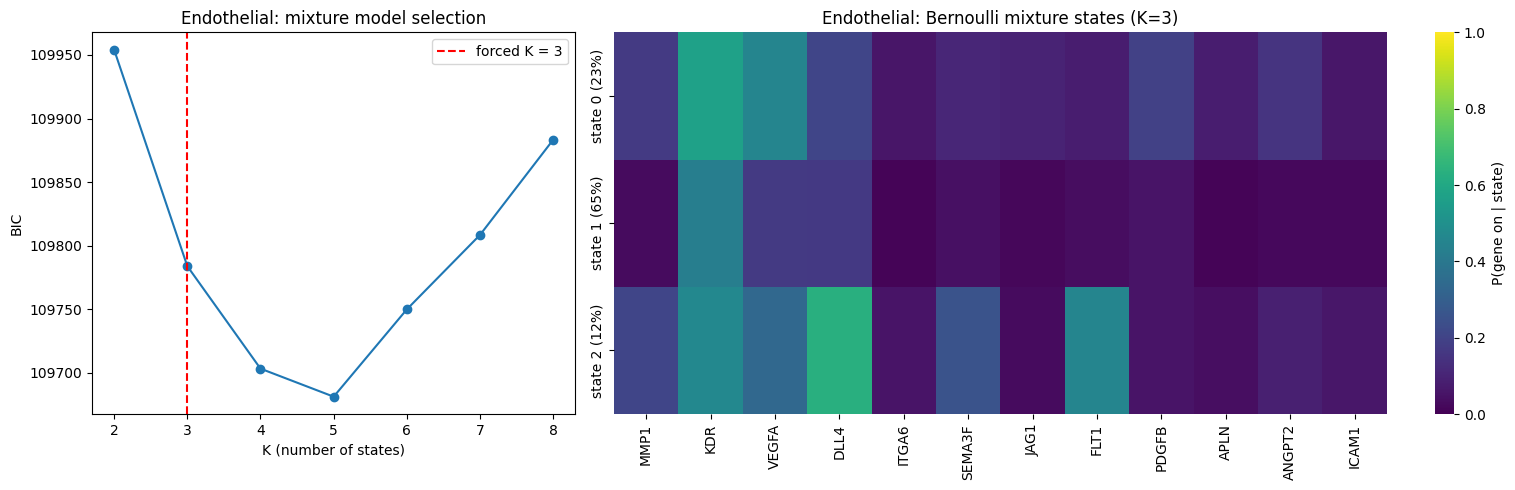

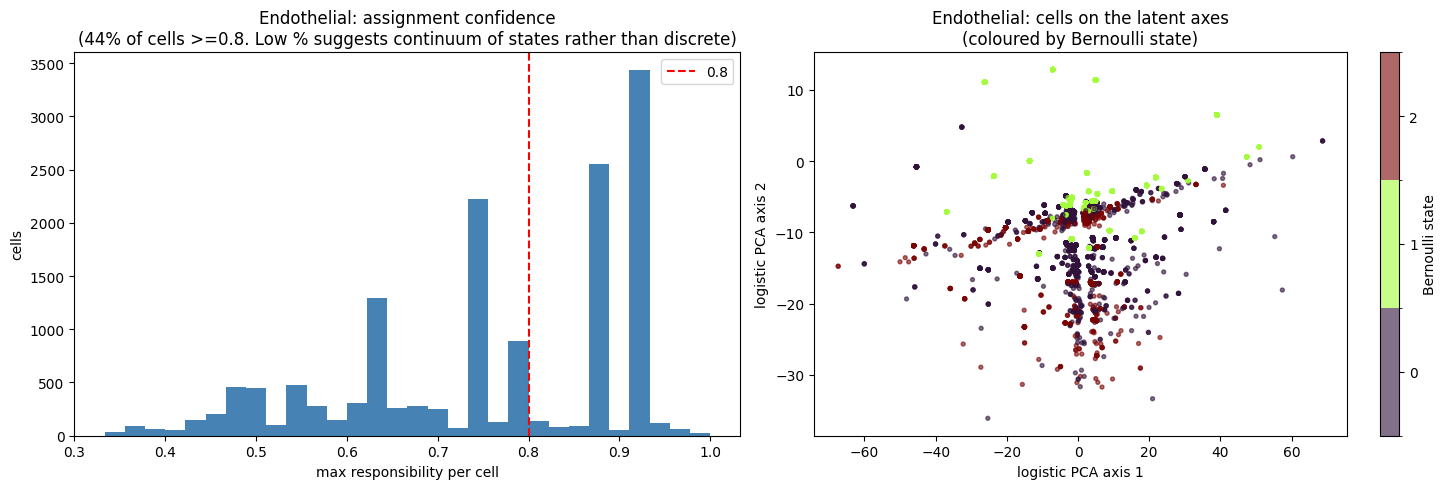

axis 1:  + end = PDGFB, VEGFA, ICAM1, SEMA3F   <-->   - end = KDR, DLL4, ANGPT2, ITGA6
axis 2:  + end = ANGPT2, PDGFB, ITGA6, APLN   <-->   - end = VEGFA, DLL4, MMP1, FLT1


,axis 1,axis 2
KDR,-0.97,-0.12
DLL4,-0.13,-0.16
ANGPT2,-0.06,-0.06
ITGA6,-0.05,-0.09
FLT1,-0.02,-0.15
MMP1,-0.00,-0.15
APLN,0.00,-0.10
JAG1,0.03,-0.11
SEMA3F,0.06,-0.14
ICAM1,0.07,-0.12


In [41]:
assigned_endothelial_cells = cluster_and_report(all_data, "Endothelial", max_clusters=8, exclude_genes=combined_marker_genes,  force_k=3)  

POPULATION: Fibroblast  (2,911 cells with reads)


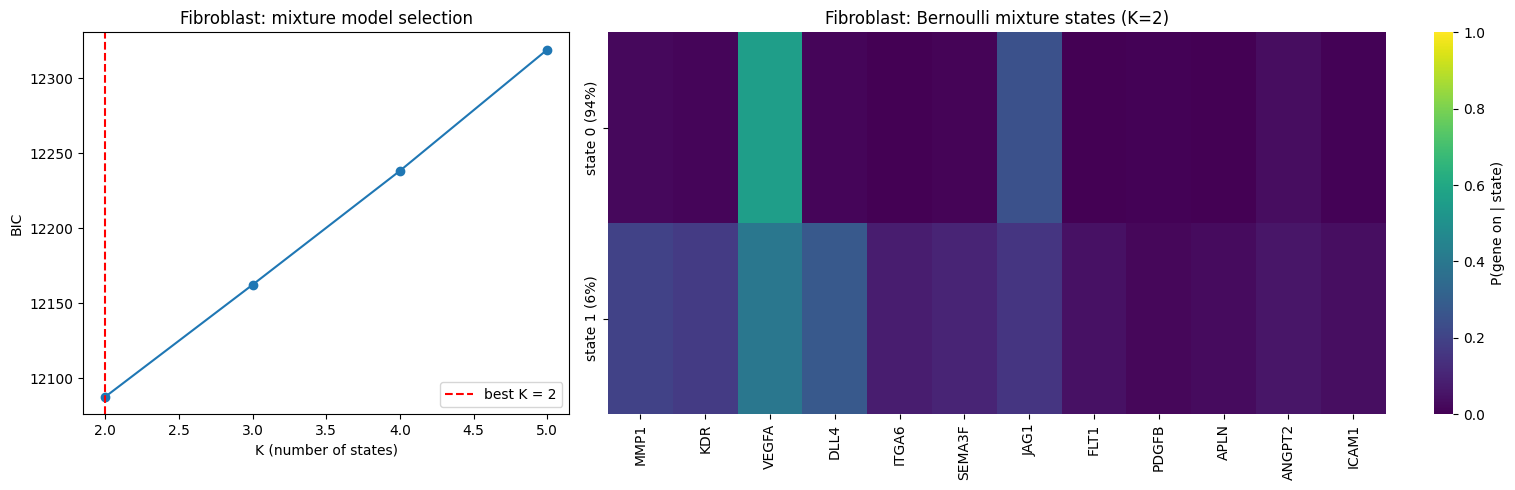

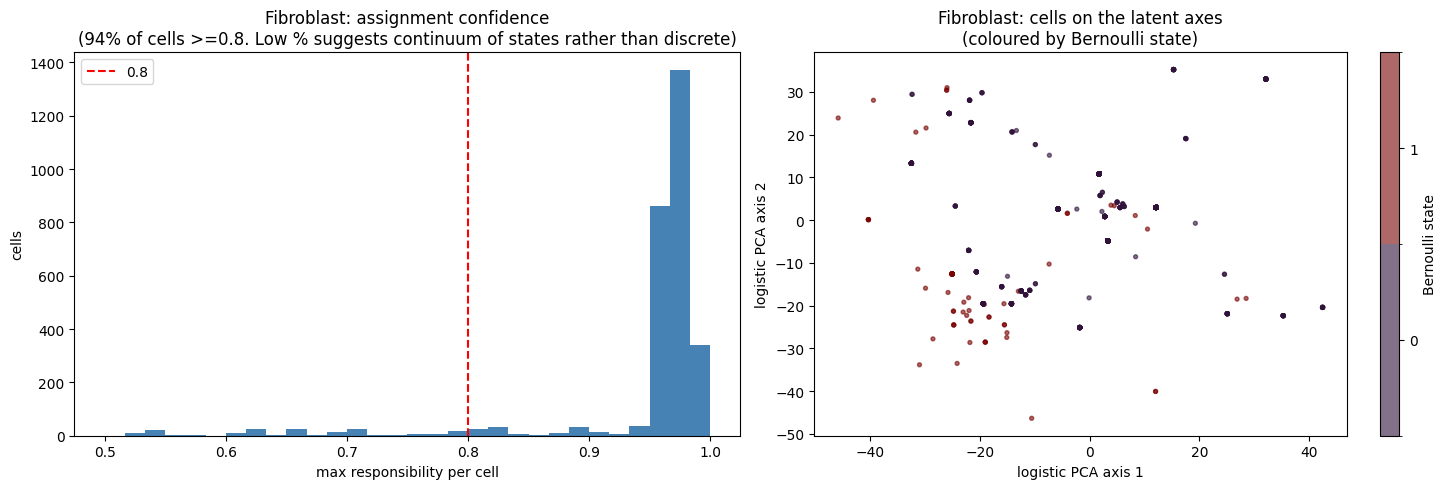

axis 1:  + end = VEGFA, JAG1, SEMA3F, APLN   <-->   - end = KDR, DLL4, FLT1, ITGA6
axis 2:  + end = JAG1, ANGPT2, PDGFB, KDR   <-->   - end = VEGFA, MMP1, SEMA3F, DLL4


,axis 1,axis 2
KDR,-0.18,0.01
DLL4,-0.16,-0.10
FLT1,-0.10,-0.02
ITGA6,-0.10,-0.08
ICAM1,-0.09,-0.05
PDGFB,-0.07,0.14
MMP1,-0.01,-0.29
ANGPT2,0.02,0.17
APLN,0.03,-0.02
SEMA3F,0.04,-0.19


In [42]:
assigned_fibroblasts = cluster_and_report(all_data, "Fibroblast", max_clusters=5,  exclude_genes=combined_marker_genes, force_k=None)  

In [43]:
assigned_endothelial_cells

,cell,cell_type,bernoulli_state,max_responsibility
0,1,Endothelial,1,0.917761
1,2,Endothelial,1,0.917761
2,4,Endothelial,1,0.870904
3,5,Endothelial,2,0.755192
4,6,Endothelial,1,0.748492
...,...,...,...,...
14758,28144,Endothelial,1,0.536811
14759,28145,Endothelial,2,0.749568
14760,28146,Endothelial,1,0.870904
14761,28150,Endothelial,1,0.917761


In [44]:
assigned_cells = pd.concat([assigned_endothelial_cells, assigned_fibroblasts])
assigned_cells["cluster_name"] = assigned_cells["cell_type"].astype(str) + "_" + assigned_cells["bernoulli_state"].astype(str)

In [45]:
def delaunay_neighbour_edges(coords, cutoff):
    """Undirected Delaunay edges (local indices) with Euclidean length <= cutoff (physical um)."""
    if len(coords) < 4:                                            # too few points for a 3D triangulation
        pairs = np.array(list(combinations(range(len(coords)), 2)), dtype=int).reshape(-1, 2)
    else:
        simplices = Delaunay(coords, qhull_options="QJ").simplices  # QJ joggles to survive coplanar/degenerate points
        pairs = np.vstack([simplices[:, [i, j]]
                           for i in range(simplices.shape[1]) for j in range(i + 1, simplices.shape[1])])
        pairs = np.unique(np.sort(pairs, axis=1), axis=0)
    if len(pairs) == 0:
        return pairs.reshape(0, 2)
    lengths = np.linalg.norm(coords[pairs[:, 0]] - coords[pairs[:, 1]], axis=1)
    return pairs[lengths <= cutoff]


def neighbour_enrichment(cells, order, title, ax, radius=SPATIAL_RADIUS_UM, n_perm=N_PERM, seed=0):
    """Within-image neighbour-enrichment permutation test + heatmap.
    Neighbours are Delaunay-adjacent cells with edge length <= radius (same image).
    Diagonal z > 0 -> a group's cells sit next to each other more than chance; off-diagonal
    z > 0 -> two groups are neighbours more than chance."""
    cells = cells[cells["group"].isin(order)].reset_index(drop=True)
    group_to_index = {group: index for index, group in enumerate(order)}
    group_codes = cells["group"].map(group_to_index).to_numpy()
    image_positions = [group.index.to_numpy() for image_name, group in cells.groupby(IMAGE_KEY)]
    edges = []
    for positions in image_positions:
        coords = cells.loc[positions, ["x_um", "y_um", "z_um"]].to_numpy()
        pairs = delaunay_neighbour_edges(coords, radius)
        if len(pairs):
            edges.extend((positions[first], positions[second]) for first, second in pairs)
    edge_array = np.array(edges, dtype=int).reshape(-1, 2) if len(edges) else np.zeros((0, 2), dtype=int)
    n_groups = len(order)

    def count_neighbour_pairs(codes):
        counts = np.zeros((n_groups, n_groups))
        if len(edge_array):
            for group_a, group_b in zip(codes[edge_array[:, 0]], codes[edge_array[:, 1]]):
                counts[group_a, group_b] += 1
                counts[group_b, group_a] += 1
        return counts

    def shuffle_labels_within_images(codes, generator):
        shuffled = codes.copy()
        for positions in image_positions:
            shuffled[positions] = generator.permutation(codes[positions])
        return shuffled

    observed = count_neighbour_pairs(group_codes)
    generator = np.random.default_rng(seed)
    permuted = np.stack([count_neighbour_pairs(shuffle_labels_within_images(group_codes, generator))
                         for permutation in range(n_perm)])
    z_matrix = (observed - permuted.mean(0)) / (permuted.std(0) + 1e-9)
    z_df = pd.DataFrame(z_matrix, index=order, columns=order)
    sns.heatmap(z_df, cmap="coolwarm", center=0, annot=True, fmt=".1f", square=True,
                ax=ax, cbar_kws={"label": "neighbour-enrichment z-score"})
    ax.set_title(title)
    return z_df


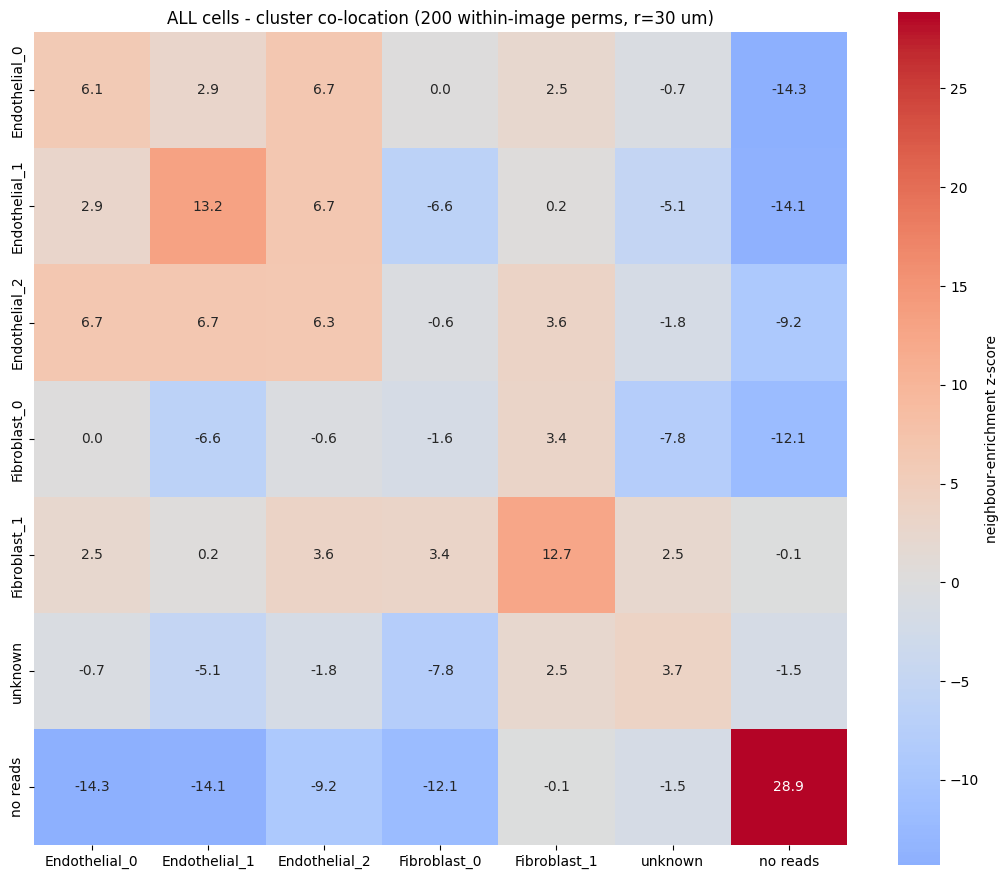

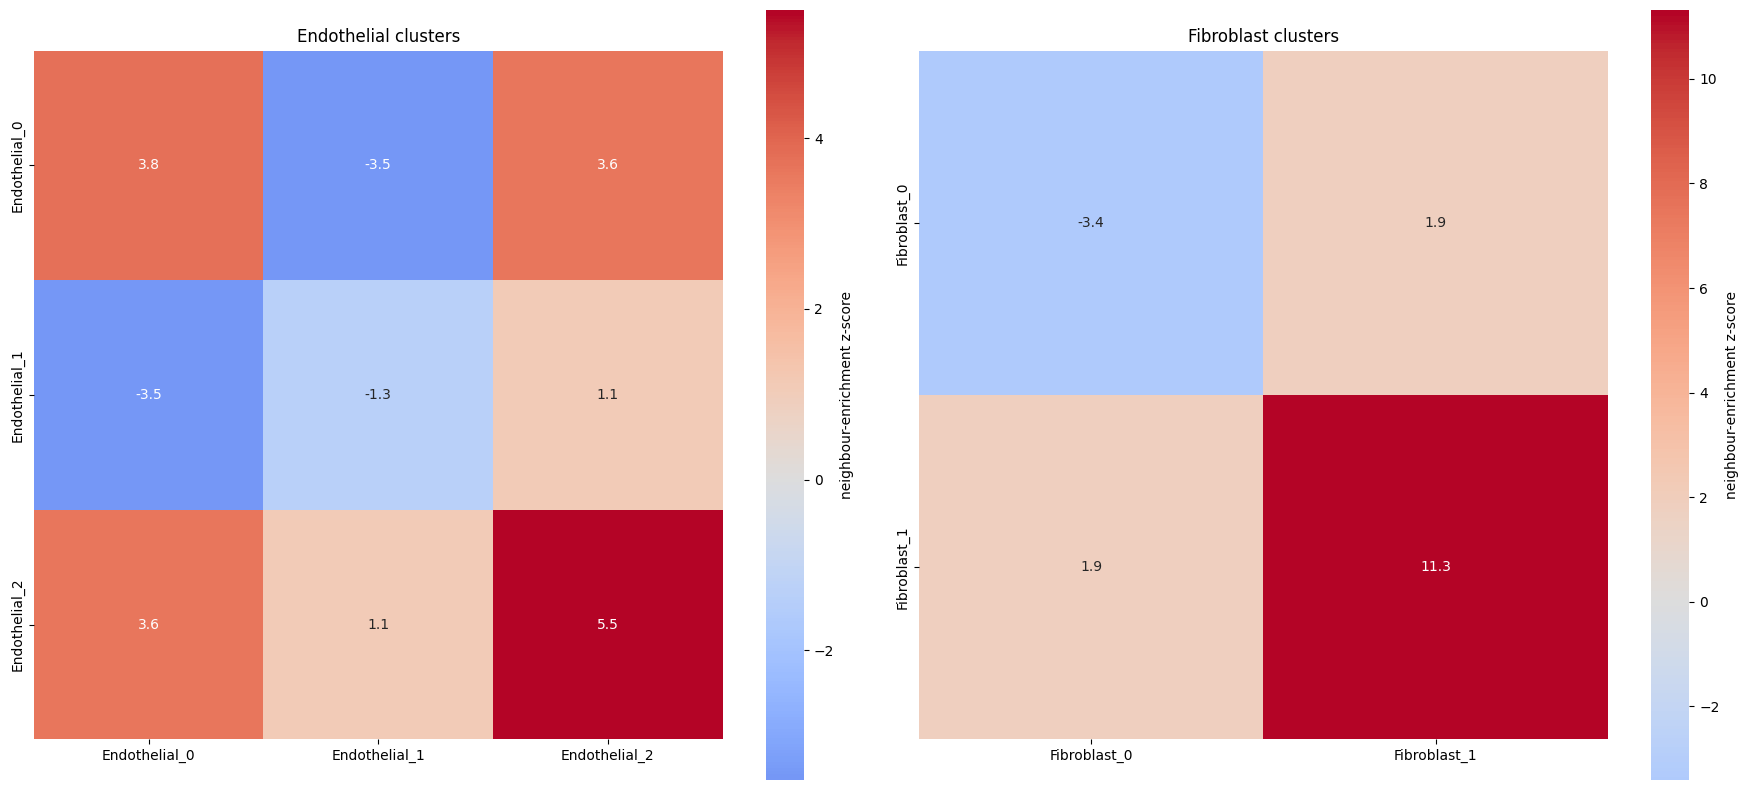

In [46]:
# Per-cell display group: cluster name for clustered cells, else "unknown" (has reads) or "no reads".
cluster_of = assigned_cells.set_index("cell")["cluster_name"]
group = pd.Series("no reads", index=all_data.index)
group[all_data["has_reads"].to_numpy()] = "unknown"
group.loc[cluster_of.index] = cluster_of.to_numpy()
df_disp = all_data.assign(group=group)

cluster_names = sorted(assigned_cells["cluster_name"].unique())
endo_names = [n for n in cluster_names if n.startswith("Endothelial")]
fibro_names = [n for n in cluster_names if n.startswith("Fibroblast")]
all_order = cluster_names + ["unknown", "no reads"]

# (1) ALL cells together (clusters + unknown + all-0 "no reads").
fig, ax = plt.subplots(figsize=(1.1 * len(all_order) + 3, 1.0 * len(all_order) + 2))
z_all = neighbour_enrichment(df_disp, all_order,
                             f"ALL cells - cluster co-location ({N_PERM} within-image perms, "
                             f"r={SPATIAL_RADIUS_UM:.0f} um)", ax)
plt.tight_layout(); plt.show()

# (2) Endothelial-only and (3) fibroblast-only (clusters within each lineage).
fig, axes = plt.subplots(1, 2, figsize=(9 * 2, 8))
neighbour_enrichment(df_disp[df_disp["cell_type"] == "Endothelial"], endo_names,
                     "Endothelial clusters", axes[0])
neighbour_enrichment(df_disp[df_disp["cell_type"] == "Fibroblast"], fibro_names,
                     "Fibroblast clusters", axes[1])
plt.tight_layout(); plt.show()